# Detecting Dementia using Natural Language Processing
DAT 550 | Final Project | B M Nafis Fuad 

### 01. Project Overview

**Goal:** 
- Predict whether a person has dementia based on their speech transcript using Natural Language Processing (NLP) and Machine Learning (ML).

**Input:**
- Transcripts of conversations (from DementiaBank).
- Metadata (Patient Age, Gender, MMSE scores, etc.).

**Output:**
- A label for each subject: Dementia or Control (i.e., no dementia).

**Type of Task:**
- *Supervised Learning:* This is a supervised classification problem, as it has labeled data (Dementia vs Control) for training.
- *Pattern Detection:* The aim is to find patterns in language that distinguish between dementia and control groups.

**Possible Challenges:**
- Data quality (e.g., missing or noisy transcripts).
- Variability in language use across individuals
- Choosing the right linguistic features or embeddings
- Possibly limited data.

**Guidelines & Instructions:**
- Project Guidelines: https://stavanger.instructure.com/courses/15609/pages/project
- Introductory Meeting PDF: https://stavanger.instructure.com/courses/15609/discussion_topics/237434
- Labels of the test set: https://stavanger.instructure.com/courses/15609/discussion_topics/237528

### 02. Data Exploration & Visualization

In [ ]:
import pandas as pd
import numpy as np

# Load the Datasets
dementia_df = pd.read_csv("Datasets/Dementia_db.csv")
control_df = pd.read_csv("Datasets/Control_db.csv")
testing_df = pd.read_csv("Datasets/Testing_db.csv")

In [467]:
dementia_df.head()

,Language,Data,Participant,Age,Gender,Diagnosis,Category,mmse,Filename,Transcript
0,eng,Pitt,PAR,59,male,ProbableAD,1,11,S079,mhm . there's a young boy &uh going in a cook...
1,eng,Pitt,PAR,55,male,ProbableAD,1,19,S080,okay he's fallin(g) off a chair [: stool] [* ...
2,eng,Pitt,PAR,69,male,ProbableAD,1,19,S081,<well the kid> [//] the girl's laughin(g) at ...
3,eng,Pitt,PAR,66,male,ProbableAD,1,11,S082,&=clears:throat well &=clears:throat &uh the ...
4,eng,Pitt,PAR,52,male,Memory,1,30,S083,okay . &uh we see a [/] &uh a &b little boy c...


In [468]:
control_df.head()

,Language,Data,Participant,Age,Gender,Diagnosis,Category,mmse,Filename,Transcript
0,eng,Pitt,PAR,74,male,Control,0,NaN,S001,well there's a mother standing there &uh &uh ...
1,eng,Pitt,PAR,62,female,Control,0,30.0,S002,somebody's getting cookies out_of the cookie ...
2,eng,Pitt,PAR,69,female,Control,0,29.0,S003,okay . there's a little boy and <he's getting...
3,eng,Pitt,PAR,71,female,Control,0,30.0,S004,are you ready ? &um well the sink is overflow...
4,eng,Pitt,PAR,74,female,Control,0,30.0,S005,okay . <many &dish or> [//] the mother's wash...


In [469]:
testing_df.head()

,Data,Participant,Age,Gender,Diagnosis,Category,mmse,Filename,Transcript
0,Pitt,PAR,63,female,Control,0,28,S160,&uh this boy is about to fall off o(f) the st...
1,Pitt,PAR,55,female,Control,0,29,S161,&uh a boy with a cookie in his one hand and h...
2,Pitt,PAR,67,female,ProbableAD,1,24,S162,"I see &uh two kids up at the cookie jar, one ..."
3,Pitt,PAR,71,male,Control,0,30,S163,okay the water's running out_of the sink over...
4,Pitt,PAR,73,female,ProbableAD,1,21,S164,well he's into the cookie jar and the [/] the...


In [470]:
print("control_df:", control_df.shape, "→ Rows:", control_df.shape[0], "| Columns:", control_df.shape[1])
print("dementia_df:", dementia_df.shape, "→ Rows:", dementia_df.shape[0], "| Columns:", dementia_df.shape[1])
print("test_df:", testing_df.shape, "→ Rows:", testing_df.shape[0], "| Columns:", testing_df.shape[1])

control_df: (54, 10) → Rows: 54 | Columns: 10
dementia_df: (54, 10) → Rows: 54 | Columns: 10
test_df: (48, 9) → Rows: 48 | Columns: 9


In [471]:
# Unique values summary for control_df
control_summary = pd.DataFrame({
    "Column": control_df.columns,
    "Num_Unique_Values": [control_df[col].nunique() for col in control_df.columns],
    "Unique_Values_Sample": [control_df[col].unique()[:5] for col in control_df.columns]
})
print("Unique values summary for Control_db.csv")
control_summary

Unique values summary for Control_db.csv


,Column,Num_Unique_Values,Unique_Values_Sample
0,Language,1,[eng]
1,Data,1,[Pitt]
2,Participant,1,[PAR]
3,Age,22,"[74, 62, 69, 71, 67]"
4,Gender,2,"[male, female]"
5,Diagnosis,1,[Control]
6,Category,1,[0]
7,mmse,5,"[nan, 30.0, 29.0, 28.0, 27.0]"
8,Filename,54,"[S001, S002, S003, S004, S005]"
9,Transcript,54,[ well there's a mother standing there &uh &uh...


In [472]:
# Unique values summary for dementia_df
dementia_summary = pd.DataFrame({
    "Column": dementia_df.columns,
    "Num_Unique_Values": [dementia_df[col].nunique() for col in dementia_df.columns],
    "Unique_Values_Sample": [dementia_df[col].unique()[:5] for col in dementia_df.columns]
})
print("Unique values summary for Dementia_db.csv")
dementia_summary

Unique values summary for Dementia_db.csv


,Column,Num_Unique_Values,Unique_Values_Sample
0,Language,1,[eng]
1,Data,1,[Pitt]
2,Participant,1,[PAR]
3,Age,21,"[59, 55, 69, 66, 52]"
4,Gender,2,"[male, female]"
5,Diagnosis,4,"[ProbableAD, Memory, Vascular, PossibleAD]"
6,Category,1,[1]
7,mmse,21,"[11, 19, 30, 21, 18]"
8,Filename,54,"[S079, S080, S081, S082, S083]"
9,Transcript,54,[ mhm . there's a young boy &uh going in a coo...


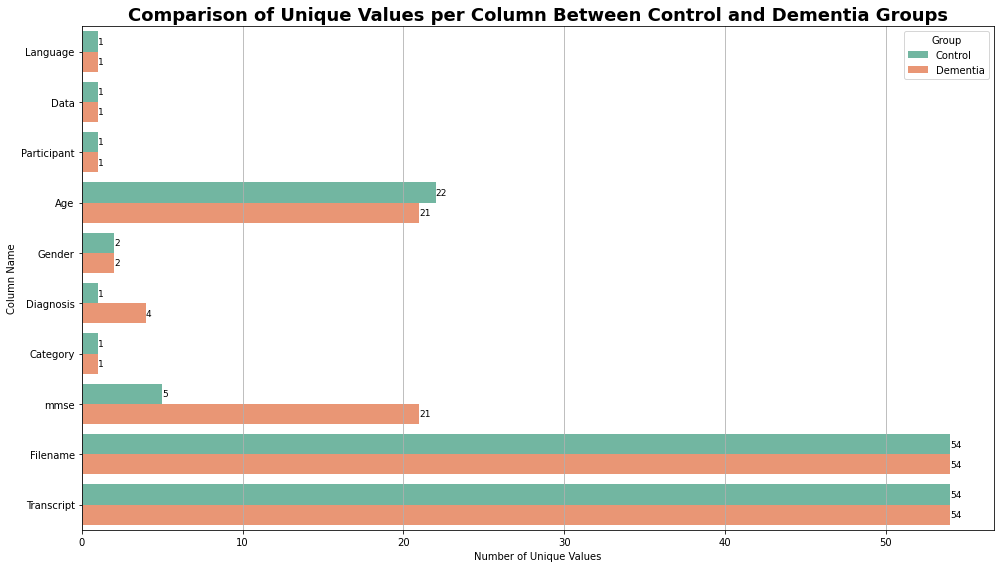

In [473]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge control and dementia summaries into one DataFrame
combined_summary = pd.DataFrame({
    'Column': control_summary['Column'],
    'Control': control_summary['Num_Unique_Values'],
    'Dementia': dementia_summary['Num_Unique_Values']
})

# Melt the DataFrame into long format for seaborn
combined_melted = combined_summary.melt(id_vars='Column', value_vars=['Control', 'Dementia'],
                                         var_name='Group', value_name='Num_Unique_Values')

# Plot
plt.figure(figsize=(14, 8))
ax = sns.barplot(x='Num_Unique_Values', y='Column', hue='Group', data=combined_melted, palette='Set2')

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9)

# Titles and labels
plt.title("Comparison of Unique Values per Column Between Control and Dementia Groups", fontsize=18, fontweight='bold')
plt.xlabel("Number of Unique Values")
plt.ylabel("Column Name")
plt.legend(title="Group")
plt.grid(axis='x')
plt.tight_layout()
plt.show()


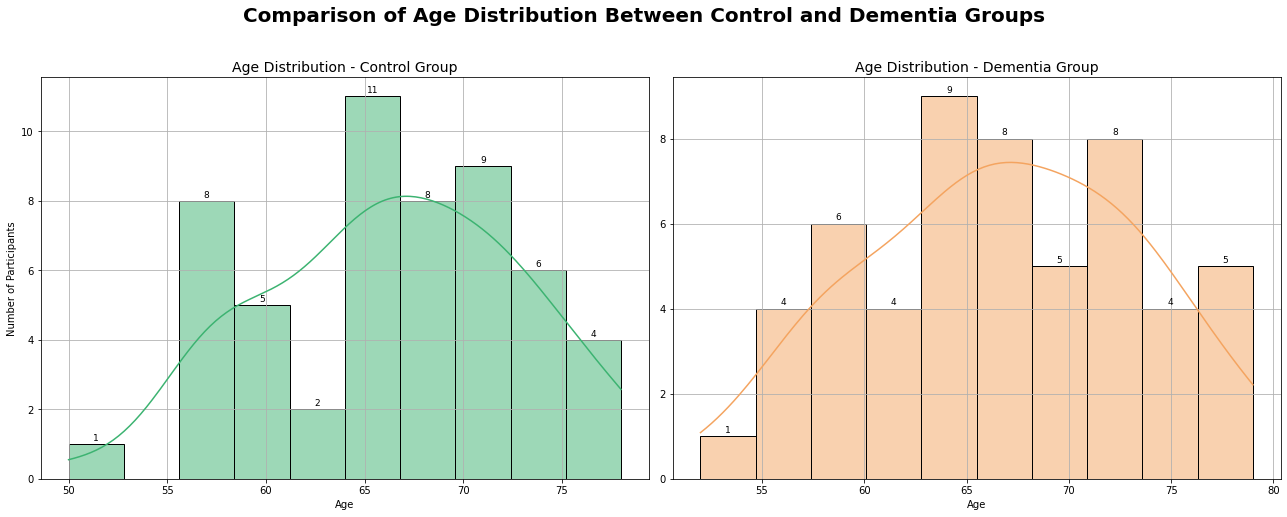

In [474]:
# Comparison of Age Distribution Between Control and Dementia Groups
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left Plot: Control Group Age ---
sns_hist_control = sns.histplot(control_df['Age'], bins=10, kde=True, color='mediumseagreen', ax=axes[0])
axes[0].set_title("Age Distribution - Control Group", fontsize=14)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of Participants")
axes[0].grid()

# Annotate bars for Control group
for p in sns_hist_control.patches:
    height = p.get_height()
    if height > 0:  # Avoid annotating empty bars
        axes[0].text(p.get_x() + p.get_width() / 2, height + 0.1, int(height), ha='center', fontsize=9)

# --- Right Plot: Dementia Group Age ---
sns_hist_dementia = sns.histplot(dementia_df['Age'], bins=10, kde=True, color='sandybrown', ax=axes[1])
axes[1].set_title("Age Distribution - Dementia Group", fontsize=14)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("")
axes[1].grid()

# Annotate bars for Dementia group
for p in sns_hist_dementia.patches:
    height = p.get_height()
    if height > 0:
        axes[1].text(p.get_x() + p.get_width() / 2, height + 0.1, int(height), ha='center', fontsize=9)

fig.suptitle("Comparison of Age Distribution Between Control and Dementia Groups", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

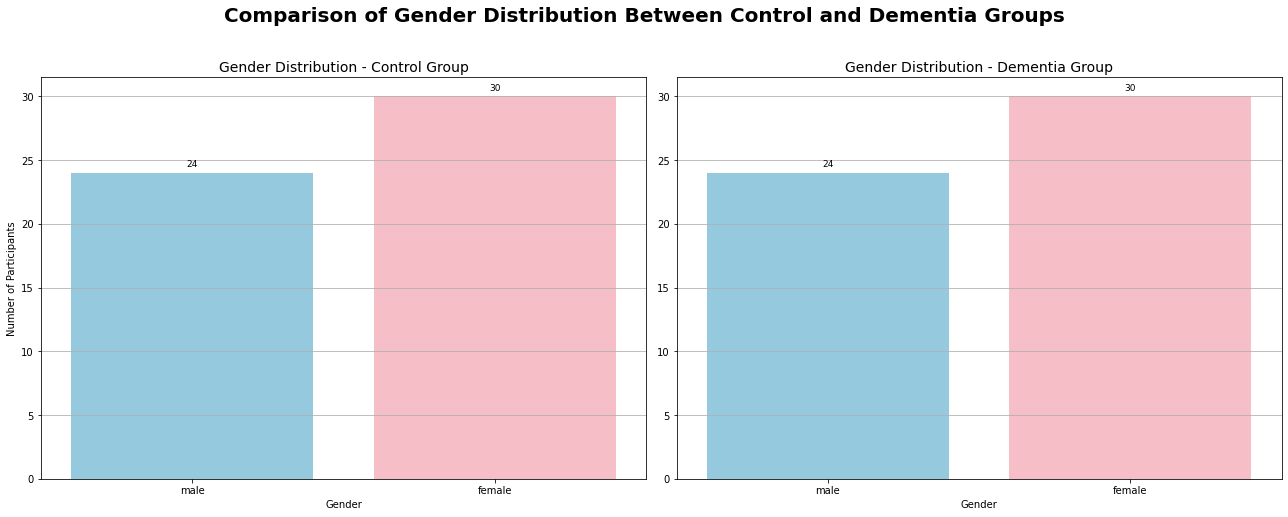

In [475]:
# Comparison of Gender Distribution Between Control and Dementia Groups
palette_gender = ['skyblue', 'lightpink']
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left Plot: Control Group Gender ---
sns_gender_control = sns.countplot(x='Gender', data=control_df, palette=palette_gender, order=['male', 'female'], ax=axes[0])
axes[0].set_title("Gender Distribution - Control Group", fontsize=14)
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Number of Participants")
axes[0].grid(axis='y')

# Annotate bars for Control group
for p in sns_gender_control.patches:
    height = p.get_height()
    if height > 0:
        axes[0].text(p.get_x() + p.get_width() / 2, height + 0.5, int(height), ha='center', fontsize=9)

# --- Right Plot: Dementia Group Gender ---
sns_gender_dementia = sns.countplot(x='Gender', data=dementia_df, palette=palette_gender, order=['male', 'female'], ax=axes[1])
axes[1].set_title("Gender Distribution - Dementia Group", fontsize=14)
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("")
axes[1].grid(axis='y')

# Annotate bars for Dementia group
for p in sns_gender_dementia.patches:
    height = p.get_height()
    if height > 0:
        axes[1].text(p.get_x() + p.get_width() / 2, height + 0.5, int(height), ha='center', fontsize=9)

fig.suptitle("Comparison of Gender Distribution Between Control and Dementia Groups", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

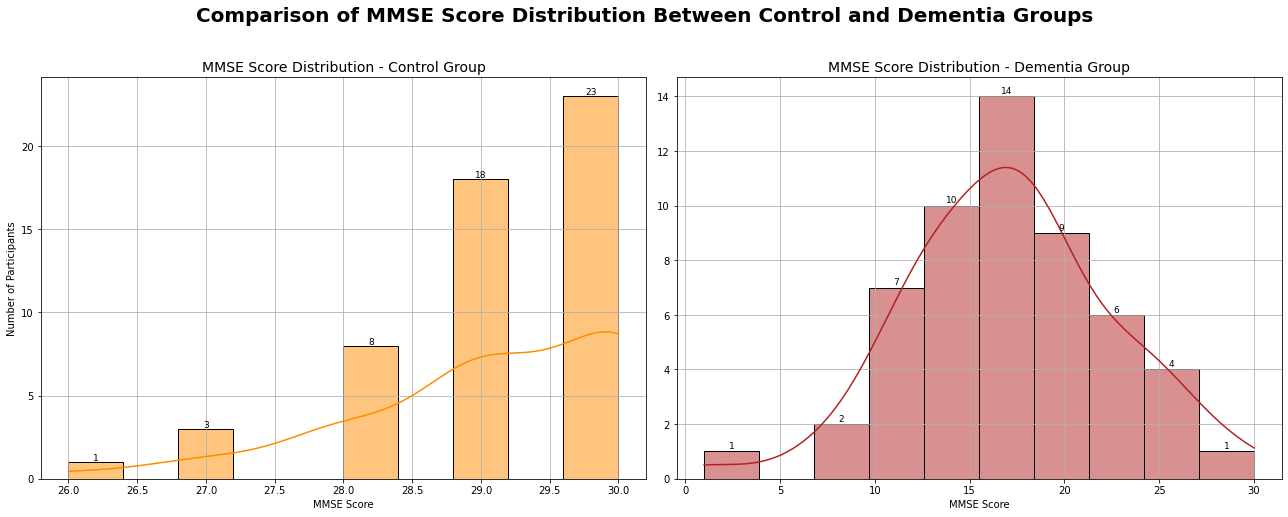

In [476]:
# Comparison of MMSE Score Distribution Between Control and Dementia Groups
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left Plot: Control Group MMSE ---
sns_hist_control = sns.histplot(control_df['mmse'], bins=10, kde=True, color='darkorange', ax=axes[0])
axes[0].set_title("MMSE Score Distribution - Control Group", fontsize=14)
axes[0].set_xlabel("MMSE Score")
axes[0].set_ylabel("Number of Participants")
axes[0].grid()

# Annotate bars for Control group
for p in sns_hist_control.patches:
    height = p.get_height()
    if height > 0:
        axes[0].text(p.get_x() + p.get_width() / 2, height + 0.1, int(height), ha='center', fontsize=9)

# --- Right Plot: Dementia Group MMSE ---
sns_hist_dementia = sns.histplot(dementia_df['mmse'], bins=10, kde=True, color='firebrick', ax=axes[1])
axes[1].set_title("MMSE Score Distribution - Dementia Group", fontsize=14)
axes[1].set_xlabel("MMSE Score")
axes[1].set_ylabel("")
axes[1].grid()

# Annotate bars for Dementia group
for p in sns_hist_dementia.patches:
    height = p.get_height()
    if height > 0:
        axes[1].text(p.get_x() + p.get_width() / 2, height + 0.1, int(height), ha='center', fontsize=9)

fig.suptitle("Comparison of MMSE Score Distribution Between Control and Dementia Groups", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

**Analysis**

This plot shows how MMSE scores are distributed across both classes. Control subjects are clustered around the high end, mostly between 10 to 30, indicating good cognitive health. On the other hand, dementia patients (orange) have a wider and lower distribution, often scoring below 26, consistent with cognitive decline. Their scores are especially clustered around 15 to 25. This is expected, as lower MMSE scores indicate more severe cognitive impairment.

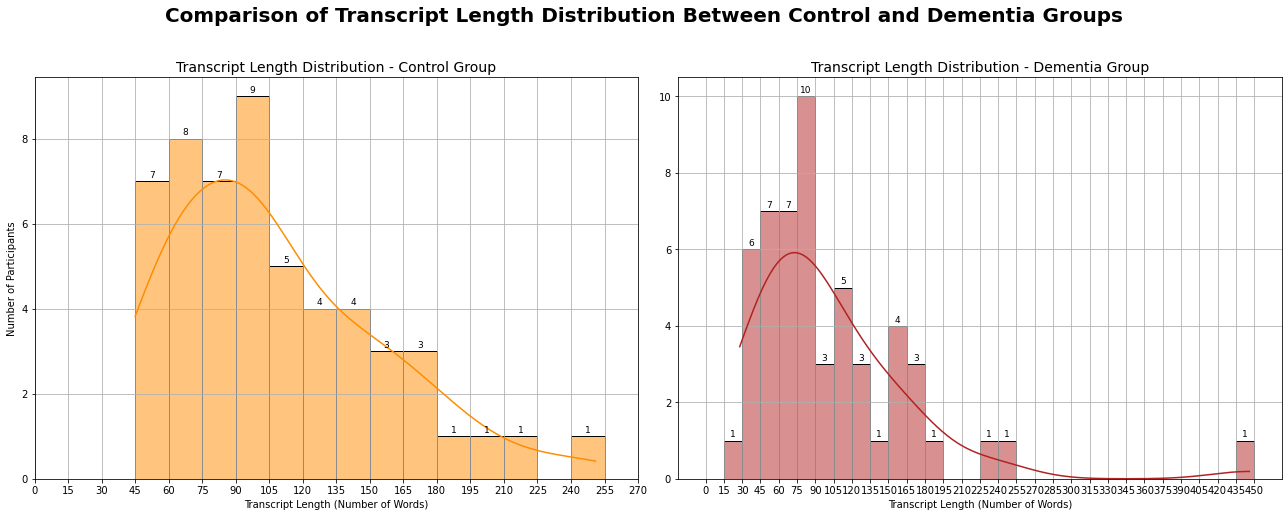


Transcript Length Range : Control Group Participants - Dementia Group Participants
 15–30  : 0 - 1
 30–45  : 0 - 6
 45–60  : 7 - 7
 60–75  : 8 - 7
 75–90  : 7 - 10
 90–105 : 9 - 3
105–120 : 5 - 5
120–135 : 4 - 3
135–150 : 4 - 1
150–165 : 3 - 4
165–180 : 3 - 3
180–195 : 1 - 1
195–210 : 1 - 0
210–225 : 1 - 0
225–240 : 0 - 1
240–255 : 1 - 1
435–450 : 0 - 1


In [477]:
# Comparison of Transcript Length Distribution Between Control and Dementia Groups
# --- Calculate Transcript Length ---
control_df['Transcript_Length'] = control_df['Transcript'].apply(lambda x: len(str(x).split()))
dementia_df['Transcript_Length'] = dementia_df['Transcript'].apply(lambda x: len(str(x).split()))

# --- Set custom bins for both groups (using the max length across both) ---
max_len = max(control_df['Transcript_Length'].max(), dementia_df['Transcript_Length'].max())
bin_width = 15 
bins = np.arange(0, max_len + bin_width + 1, bin_width)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# --- Left Plot: Control Group ---
sns_hist_control = sns.histplot(
    control_df['Transcript_Length'],
    bins=bins,
    kde=True,
    color='darkorange',
    ax=axes[0]
)
axes[0].set_title("Transcript Length Distribution - Control Group", fontsize=14)
axes[0].set_xlabel("Transcript Length (Number of Words)")
axes[0].set_ylabel("Number of Participants")
axes[0].set_xticks(bins)
axes[0].grid(True)
axes[0].set_xlim(0, 270)

# Annotate bars for Control
for p in sns_hist_control.patches:
    height = p.get_height()
    if height > 0:
        axes[0].text(p.get_x() + p.get_width() / 2, height + 0.1, int(height),
                     ha='center', fontsize=9)

# --- Right Plot: Dementia Group ---
sns_hist_dementia = sns.histplot(
    dementia_df['Transcript_Length'],
    bins=bins,
    kde=True,
    color='firebrick',
    ax=axes[1]
)
axes[1].set_title("Transcript Length Distribution - Dementia Group", fontsize=14)
axes[1].set_xlabel("Transcript Length (Number of Words)")
axes[1].set_ylabel("")
axes[1].set_xticks(bins)
axes[1].grid(True)

# Annotate bars for Dementia
for p in sns_hist_dementia.patches:
    height = p.get_height()
    if height > 0:
        axes[1].text(p.get_x() + p.get_width() / 2, height + 0.1, int(height),
                     ha='center', fontsize=9)

fig.suptitle("Comparison of Transcript Length Distribution Between Control and Dementia Groups", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# --- Create histogram counts for both groups ---
counts_control, bin_edges = np.histogram(control_df['Transcript_Length'], bins=bins)
counts_dementia, _ = np.histogram(dementia_df['Transcript_Length'], bins=bins)

print("\nTranscript Length Range : Control Group Participants - Dementia Group Participants")
for i in range(len(counts_control)):
    if counts_control[i] > 0 or counts_dementia[i] > 0:
        print(f"{bin_edges[i]:>3.0f}–{bin_edges[i+1]:<3.0f} : {counts_control[i]} - {counts_dementia[i]}")


**Analysis:**

Dementia participants tend to produce shorter transcripts, especially visible in the <90 word range. Control participants tend to have longer and more consistent transcript lengths, especially in the 90–180 range. These patterns are useful for feature engineering and validate transcript length as a discriminative feature in modeling.

### 03. Preprocessing & Data Cleaning

##### Approach 01: By Removing Stopwords

In [478]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
# Reload the CSV files
dementia_df_train = pd.read_csv("Datasets/Dementia_db.csv")
control_df_train = pd.read_csv("Datasets/Control_db.csv")

# Combine dementia and control datasets into a single training dataset
dementia_df_train['Label'] = 1  # Dementia
control_df_train['Label'] = 0   # Control
train_df_wo_Stopwords = pd.concat([dementia_df_train, control_df_train], ignore_index=True)

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Function to clean and preprocess transcript
def clean_transcript_Stopwords(text, remove_stopwords=True, do_lemmatize=True):
    text = str(text).lower()
    text = re.sub(r"\[.*?\]", "", text)         # Remove [noise], [//], etc.
    text = re.sub(r"<.*?>", "", text)           # Remove <tags>
    text = re.sub(r"&[^\s]+", "", text)         # Remove &uh, &um, &clears:throat etc.
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)  # Remove ALL punctuation (except spaces)
    text = re.sub(r"\s+", " ", text)            # Normalize Whitespace
    text = re.sub(r"\bxxx\b", "", text)         # Remove 'xxx' exactly
    text = re.sub(r"\buhh?-huh\b", "", text)    # Remove 'uh-huh' or 'uhh-huh'
    words = text.strip().split()
    if remove_stopwords:
        words = [word for word in words if word not in stop_words]    
    if do_lemmatize:
        words = [lemmatizer.lemmatize(word) for word in words]    
    return " ".join(words)

# Apply preprocessing function to the transcript column
train_df_wo_Stopwords["Cleaned_Transcript"] = train_df_wo_Stopwords["Transcript"].apply(clean_transcript_Stopwords)

# Handle missing MMSE scores by filling with median of respective class
train_df_wo_Stopwords['mmse'] = train_df_wo_Stopwords.groupby('Label')['mmse'].transform(lambda x: x.fillna(x.median()))

# Encode gender to numeric
gender_map = {"male": 0, "female": 1}
train_df_wo_Stopwords["GenderEncoded"] = train_df_wo_Stopwords["Gender"].map(gender_map)

# Word count based on Cleaned_Transcript
train_df_wo_Stopwords['Transcript_Length'] = train_df_wo_Stopwords['Cleaned_Transcript'].apply(lambda x: len(x.split()))

train_df_wo_Stopwords

,Language,Data,Participant,Age,Gender,Diagnosis,Category,mmse,Filename,Transcript,Label,Cleaned_Transcript,GenderEncoded,Transcript_Length
0,eng,Pitt,PAR,59,male,ProbableAD,1,11.0,S079,mhm . there's a young boy &uh going in a cook...,1,mhm there young boy going cookie jar there gir...,0,45
1,eng,Pitt,PAR,55,male,ProbableAD,1,19.0,S080,okay he's fallin(g) off a chair [: stool] [* ...,1,okay he falling chair shes running water cant ...,0,16
2,eng,Pitt,PAR,69,male,ProbableAD,1,19.0,S081,<well the kid> [//] the girl's laughin(g) at ...,1,girl laughing brother mother mother sink sink ...,0,62
3,eng,Pitt,PAR,66,male,ProbableAD,1,11.0,S082,&=clears:throat well &=clears:throat &uh the ...,1,well kid going mother see shes inside kid gues...,0,41
4,eng,Pitt,PAR,52,male,Memory,1,30.0,S083,okay . &uh we see a [/] &uh a &b little boy c...,1,okay see little boy climbed stool reaching sto...,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,eng,Pitt,PAR,74,male,Control,0,29.0,S071,the kids are in the cookies . the stool is fa...,0,kid cooky stool falling mother spilling water ...,0,26
104,eng,Pitt,PAR,75,male,Control,0,29.0,S072,you mean right now tell you ? &uh the boy is ...,0,mean right tell boy stealing cooky outof jar h...,0,43
105,eng,Pitt,PAR,61,male,Control,0,29.0,S073,well ‡ the boy's trying to get in this cookie...,0,well boy trying get cookie jar stool overturn ...,0,36
106,eng,Pitt,PAR,78,female,Control,0,28.0,S076,mhm . mhm a_lot_of things are happening . yes...,0,mhm mhm alotof thing happening yes water going...,1,36


##### Approach 02: Without Removing Stopwords

In [ ]:
# Reload the CSV files
dementia_df_train = pd.read_csv("Datasets/Dementia_db.csv")
control_df_train = pd.read_csv("Datasets/Control_db.csv")

# Combine dementia and control datasets into a single training dataset
dementia_df_train['Label'] = 1  # Dementia
control_df_train['Label'] = 0   # Control
train_df_with_stopwords = pd.concat([dementia_df_train, control_df_train], ignore_index=True)

# Function to clean and preprocess transcript
def clean_transcript(text, do_lemmatize=True):
    text = str(text).lower()
    text = re.sub(r"\[.*?\]", "", text)         # Remove [noise], [//], etc.
    text = re.sub(r"<.*?>", "", text)           # Remove <tags>
    text = re.sub(r"&[^\s]+", "", text)         # Remove &uh, &um, &clears:throat etc.
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)  # Remove ALL punctuation (except spaces)
    text = re.sub(r"\s+", " ", text)            # Normalize Whitespace
    text = re.sub(r"\bxxx\b", "", text)         # Remove 'xxx' exactly
    text = re.sub(r"\buhh?-huh\b", "", text)    # Remove 'uh-huh' or 'uhh-huh'
    words = text.strip().split()  
    if do_lemmatize:
        words = [lemmatizer.lemmatize(word) for word in words] 
    return " ".join(words)

# Apply preprocessing function to the transcript column
train_df_with_stopwords["Cleaned_Transcript"] = train_df_with_stopwords["Transcript"].apply(clean_transcript)

# Handle missing MMSE scores by filling with median of respective class
train_df_with_stopwords['mmse'] = train_df_with_stopwords.groupby('Label')['mmse'].transform(lambda x: x.fillna(x.median()))

# Encode gender to numeric
gender_map = {"male": 0, "female": 1}
train_df_with_stopwords["GenderEncoded"] = train_df_with_stopwords["Gender"].map(gender_map)

# Word count based on Cleaned_Transcript
train_df_with_stopwords['Transcript_Length'] = train_df_with_stopwords['Cleaned_Transcript'].apply(lambda x: len(x.split()))

train_df_with_stopwords

,Language,Data,Participant,Age,Gender,Diagnosis,Category,mmse,Filename,Transcript,Label,Cleaned_Transcript,GenderEncoded,Transcript_Length
0,eng,Pitt,PAR,59,male,ProbableAD,1,11.0,S079,mhm . there's a young boy &uh going in a cook...,1,mhm there a young boy going in a cookie jar an...,0,102
1,eng,Pitt,PAR,55,male,ProbableAD,1,19.0,S080,okay he's fallin(g) off a chair [: stool] [* ...,1,okay he falling off a chair shes running the w...,0,24
2,eng,Pitt,PAR,69,male,ProbableAD,1,19.0,S081,<well the kid> [//] the girl's laughin(g) at ...,1,the girl laughing at her brother because he an...,0,121
3,eng,Pitt,PAR,66,male,ProbableAD,1,11.0,S082,&=clears:throat well &=clears:throat &uh the ...,1,well the kid are are they they are going to an...,0,126
4,eng,Pitt,PAR,52,male,Memory,1,30.0,S083,okay . &uh we see a [/] &uh a &b little boy c...,1,okay we see a a little boy climbed up on a sto...,0,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,eng,Pitt,PAR,74,male,Control,0,29.0,S071,the kids are in the cookies . the stool is fa...,0,the kid are in the cooky the stool is falling ...,0,53
104,eng,Pitt,PAR,75,male,Control,0,29.0,S072,you mean right now tell you ? &uh the boy is ...,0,you mean right now tell you the boy is stealin...,0,88
105,eng,Pitt,PAR,61,male,Control,0,29.0,S073,well ‡ the boy's trying to get in this cookie...,0,well the boy trying to get in this cookie jar ...,0,78
106,eng,Pitt,PAR,78,female,Control,0,28.0,S076,mhm . mhm a_lot_of things are happening . yes...,0,mhm mhm alotof thing are happening yes the wat...,1,77


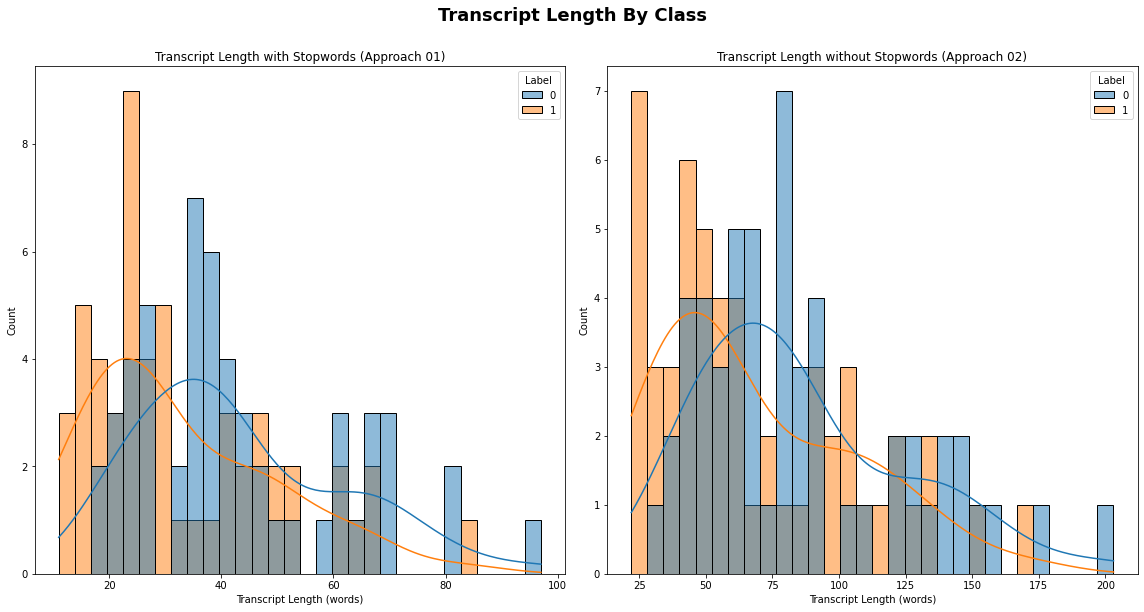

In [481]:
# Visualization of Both Approaches

# Count number of samples per Label
label_counts_wo_Stopwords = train_df_wo_Stopwords['Label'].value_counts()           
label_counts_with_stopwords = train_df_with_stopwords['Label'].value_counts()

fig = plt.figure(figsize=(16, 8))

# 1. Transcript length by class (without stopwords)
plt.subplot(1, 2, 1)
sns.histplot(data=train_df_wo_Stopwords, x='Transcript_Length', hue='Label', kde=True, bins=30)
plt.title("Transcript Length with Stopwords (Approach 01)")
plt.xlabel("Transcript Length (words)")
plt.ylabel("Count")

# 2. Transcript length by class (with stopwords)
plt.subplot(1, 2, 2)
sns.histplot(data=train_df_with_stopwords, x='Transcript_Length', hue='Label', kde=True, bins=30)
plt.title("Transcript Length without Stopwords (Approach 02)")
plt.xlabel("Transcript Length (words)")
plt.ylabel("Count")

fig.text(0.5, 0.96, "Transcript Length By Class\n\n", ha='center', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

**Analysis:** 

This plot shows the distribution of the number of words in each transcript. Here, dementia transcripts (orange) tend to be shorter on average and control transcripts (blue) are slightly longer, with more cases in the higher word count range. This reflects real-world findings as patients with dementia often speak less fluently, use simpler language, or struggle to form long sentences.



**As I'm going to use BERT and FastText in Feautre Engineering, so preprocessing without removing stopwords (Approach 02) is more suitable**

In [482]:
train_df = train_df_with_stopwords.copy()
train_df

,Language,Data,Participant,Age,Gender,Diagnosis,Category,mmse,Filename,Transcript,Label,Cleaned_Transcript,GenderEncoded,Transcript_Length
0,eng,Pitt,PAR,59,male,ProbableAD,1,11.0,S079,mhm . there's a young boy &uh going in a cook...,1,mhm there a young boy going in a cookie jar an...,0,102
1,eng,Pitt,PAR,55,male,ProbableAD,1,19.0,S080,okay he's fallin(g) off a chair [: stool] [* ...,1,okay he falling off a chair shes running the w...,0,24
2,eng,Pitt,PAR,69,male,ProbableAD,1,19.0,S081,<well the kid> [//] the girl's laughin(g) at ...,1,the girl laughing at her brother because he an...,0,121
3,eng,Pitt,PAR,66,male,ProbableAD,1,11.0,S082,&=clears:throat well &=clears:throat &uh the ...,1,well the kid are are they they are going to an...,0,126
4,eng,Pitt,PAR,52,male,Memory,1,30.0,S083,okay . &uh we see a [/] &uh a &b little boy c...,1,okay we see a a little boy climbed up on a sto...,0,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,eng,Pitt,PAR,74,male,Control,0,29.0,S071,the kids are in the cookies . the stool is fa...,0,the kid are in the cooky the stool is falling ...,0,53
104,eng,Pitt,PAR,75,male,Control,0,29.0,S072,you mean right now tell you ? &uh the boy is ...,0,you mean right now tell you the boy is stealin...,0,88
105,eng,Pitt,PAR,61,male,Control,0,29.0,S073,well ‡ the boy's trying to get in this cookie...,0,well the boy trying to get in this cookie jar ...,0,78
106,eng,Pitt,PAR,78,female,Control,0,28.0,S076,mhm . mhm a_lot_of things are happening . yes...,0,mhm mhm alotof thing are happening yes the wat...,1,77


### 04. Feature Engineering

##### 4.1. TF-IDF

In [483]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare features
X_text_tfidf = train_df['Cleaned_Transcript']
X_numeric_tfidf = train_df[['mmse', 'Transcript_Length', 'GenderEncoded', 'Age']]
y_tfidf = train_df['Label']

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(X_text_tfidf).toarray()
print(f"TF-IDF Feature Shape: {X_tfidf.shape}")

# Scale numeric features
scaler_tfidf = StandardScaler()
X_numeric_scaled_tfidf = scaler_tfidf.fit_transform(X_numeric_tfidf)

# Combine features
X_combined_tfidf = np.hstack((X_tfidf, X_numeric_scaled_tfidf))

# Split data
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(
    X_combined_tfidf, y_tfidf, test_size=0.2, stratify=y_tfidf, random_state=42)

print(f"TF-IDF + Numeric: {X_combined_tfidf.shape}, Train: {X_train_tfidf.shape}, Val: {X_val_tfidf.shape}")

TF-IDF Feature Shape: (108, 681)
TF-IDF + Numeric: (108, 685), Train: (86, 685), Val: (22, 685)


**TF-IDF + Numeric Feature Summary:**
- The dataset contains 108 samples (rows), each corresponding to a transcript.
- After applying TF-IDF vectorization, the model extracted 681 unique word features across all transcripts. Although `max_features=1000` was specified, only 681 unique terms appeared with sufficient frequency to be included.
- 4 structured numeric features were included: (i) mmse, (ii) Transcript_Length, (iii) GenderEncoded and (iv) Age.
- This results in a combined feature space of 681 (TF-IDF) + 4 (numeric) = 685 total features per sample.
- The data was split into training and validation sets using an 80/20 stratified split:
    - Training set: 86 samples, each with 685 features.
    - Validation set: 22 samples, each with 685 features.

##### 4.2. FastText Embeddings

In [484]:
!pip install gensim

In [485]:
# Download the word2vec model from this link: https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz

In [ ]:
# Trim the large .vec file to only include words in curent dataset
import os

# Extract unique words from your dataset
vocab = set()
for text in train_df["Cleaned_Transcript"]:
    words = text.split()
    vocab.update(words)
print(f"Unique words in dataset: {len(vocab)}")

# Paths
input_vec_path = "Datasets/cc.en.300.vec"       # Original downloaded .vec file
output_vec_path = "Datasets/cc.trimmed.vec"     # Trimmed .vec file

# Check if trimmed file already exists
if os.path.exists(output_vec_path):
    print(f"Trimmed file '{output_vec_path}' already exists. Skipping trimming.")
else:
    # Filter the original .vec file
    with open(input_vec_path, 'r', encoding='utf-8') as fin:
        header = fin.readline()
        trimmed_lines = []

        for line in fin:
            word = line.split(' ', 1)[0]
            if word in vocab:
                trimmed_lines.append(line)

    # Save trimmed vectors
    with open(output_vec_path, 'w', encoding='utf-8') as fout:
        fout.write(f"{len(trimmed_lines)} 300\n")
        for line in trimmed_lines:
            fout.write(line)

    print(f"Trimmed .vec file saved as '{output_vec_path}' with {len(trimmed_lines)} words.")

Unique words in dataset: 683
Trimmed .vec file saved as 'cc.trimmed.vec' with 670 words.


In [ ]:
from gensim.models import KeyedVectors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load trimmed fastText model
model_fasttext = KeyedVectors.load_word2vec_format('Datasets/cc.trimmed.vec', binary=False)

# Function to compute average fastText embeddings
def get_avg_fasttext_vector(text, model):
    words = text.split()
    vectors = [model[word] for word in words if word in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# Generate embeddings
X_text_fasttext = train_df["Cleaned_Transcript"]
X_fasttext = np.array([get_avg_fasttext_vector(text, model_fasttext) for text in X_text_fasttext])
print(f"fastText Feature Shape: {X_fasttext.shape}")

# Prepare and scale numeric features
X_numeric_fasttext = train_df[['mmse', 'Transcript_Length', 'GenderEncoded', 'Age']]
scaler_fasttext = StandardScaler()
X_numeric_scaled_fasttext = scaler_fasttext.fit_transform(X_numeric_fasttext)

# Combine embeddings + numeric
X_combined_fasttext = np.hstack((X_fasttext, X_numeric_scaled_fasttext))

# Split data
y_fasttext = train_df['Label']
X_train_fasttext, X_val_fasttext, y_train_fasttext, y_val_fasttext = train_test_split(
    X_combined_fasttext, y_fasttext, test_size=0.2, stratify=y_fasttext, random_state=42)

print(f"fastText + Numeric: {X_combined_fasttext.shape}, Train: {X_train_fasttext.shape}, Val: {X_val_fasttext.shape}")

fastText Feature Shape: (108, 300)
fastText + Numeric: (108, 304), Train: (86, 304), Val: (22, 304)


**fastText + Numeric Feature Summary:**
- The dataset contains 108 samples, each representing a participant transcript.
- Each transcript was embedded using fastText, generating a 300-dimensional dense vector. This vector represents the semantic meaning of the full transcript by averaging pretrained word embeddings from the cc.trimmed.vec model.
- In addition to the text embeddings, 4 structured numeric features were included: (i) mmse, (ii) Transcript_Length, (iii) GenderEncoded and (iv) Age.
- This resulted in a final feature vector of 300 (fastText) + 4 (numeric) = 304 features per sample.
- The data was split into training and validation sets using an 80/20 stratified split:
    - Training set: 86 samples, each with 304 features.
    - Validation set: 22 samples, each with 304 features.

##### 4.3. BERT

Unlike TF-IDF or fastText:
- BERT captures the meaning of words in context, i.e., it understands that “bank” in river bank is different from money bank.
- It generates sentence-level embeddings, typically by using the [CLS] token (a special token used to represent the entire sequence).

In [488]:
!pip install transformers torch

In [489]:
from transformers import BertTokenizer, BertModel
import torch

# Load pretrained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')


In [490]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Function to generate BERT [CLS] embeddings
def get_bert_cls_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding='max_length', max_length=128)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    cls_embedding = outputs.last_hidden_state[:, 0, :] 
    return cls_embedding.squeeze().numpy()

# Apply to the cleaned transcripts
X_bert = np.array([get_bert_cls_embedding(text) for text in train_df["Cleaned_Transcript"]])
print(f"BERT Embedding Shape: {X_bert.shape}")


# Prepare and scale numeric features
X_numeric_bert = train_df[['mmse', 'Transcript_Length', 'GenderEncoded', 'Age']]
scaler_bert = StandardScaler()
X_numeric_scaled_bert = scaler_bert.fit_transform(X_numeric_bert)

# Combine
X_combined_bert = np.hstack((X_bert, X_numeric_scaled_bert))

# Split data
y_bert = train_df['Label']
X_train_bert, X_val_bert, y_train_bert, y_val_bert = train_test_split(
    X_combined_bert, y_bert, test_size=0.2, stratify=y_bert, random_state=42)

print(f"BERT + Numeric: {X_combined_bert.shape}, Train: {X_train_bert.shape}, Val: {X_val_bert.shape}")

BERT Embedding Shape: (108, 768)
BERT + Numeric: (108, 772), Train: (86, 772), Val: (22, 772)


**BERT + Numeric Feature Summary**
- The dataset consists of 108 transcripts, each mapped to a dementia (1) or control (0) label.
- Each transcript was encoded using BERT (bert-base-uncased) via the [CLS] token, which produces a 768-dimensional dense vector per transcript. This vector captures the contextual meaning of the entire sentence, unlike fastText or TF-IDF.
- In addition to the BERT embeddings, 4 structured numeric features were included: (i) mmse, (ii) Transcript_Length, (iii) GenderEncoded and (iv) Age.
- The combined feature vector results in 768 (BERT) + 4 (numeric) = 772 total features per sample.
- A stratified 80/20 train-validation split was applied:
    - Training set: 86 samples, each with 772 features.
    - Validation set: 22 samples, each with 772 features.

### 05. Model Training


=== Evaluating Logistic Regression (TF-IDF + Numeric) ===

=== Evaluating SVM (TF-IDF + Numeric) ===

=== Evaluating Decision Tree (TF-IDF + Numeric) ===

=== Evaluating Random Forest (TF-IDF + Numeric) ===

=== Evaluating Logistic Regression (fastText + Numeric) ===

=== Evaluating SVM (fastText + Numeric) ===

=== Evaluating Decision Tree (fastText + Numeric) ===

=== Evaluating Random Forest (fastText + Numeric) ===

=== Evaluating Logistic Regression (BERT + Numeric) ===

=== Evaluating SVM (BERT + Numeric) ===

=== Evaluating Decision Tree (BERT + Numeric) ===

=== Evaluating Random Forest (BERT + Numeric) ===


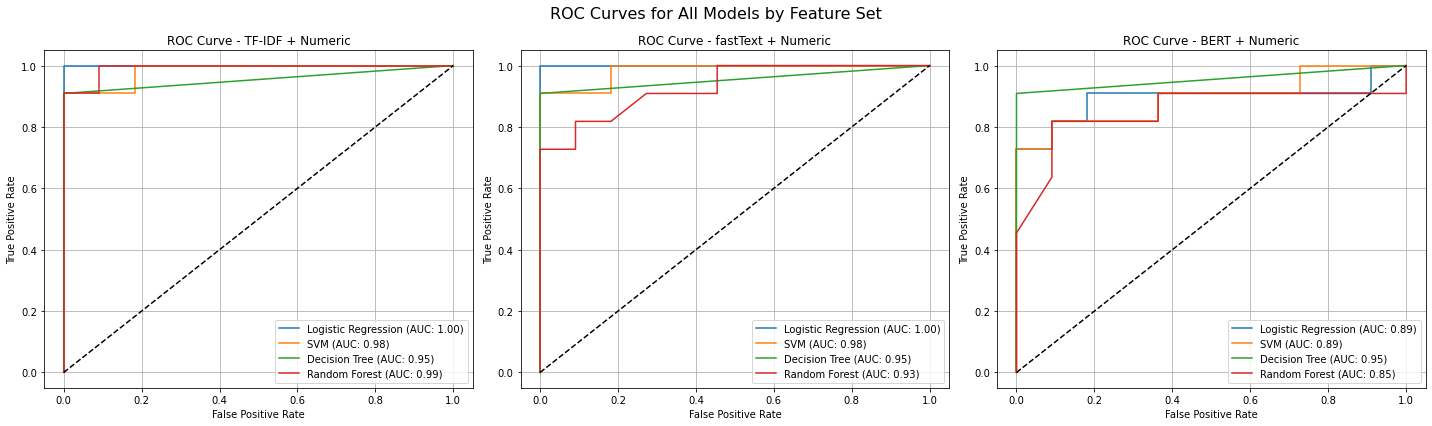

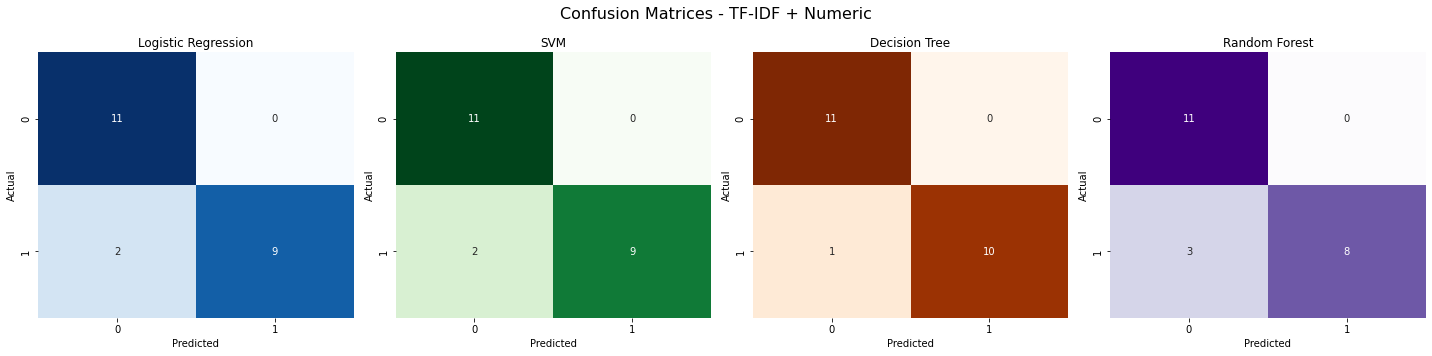

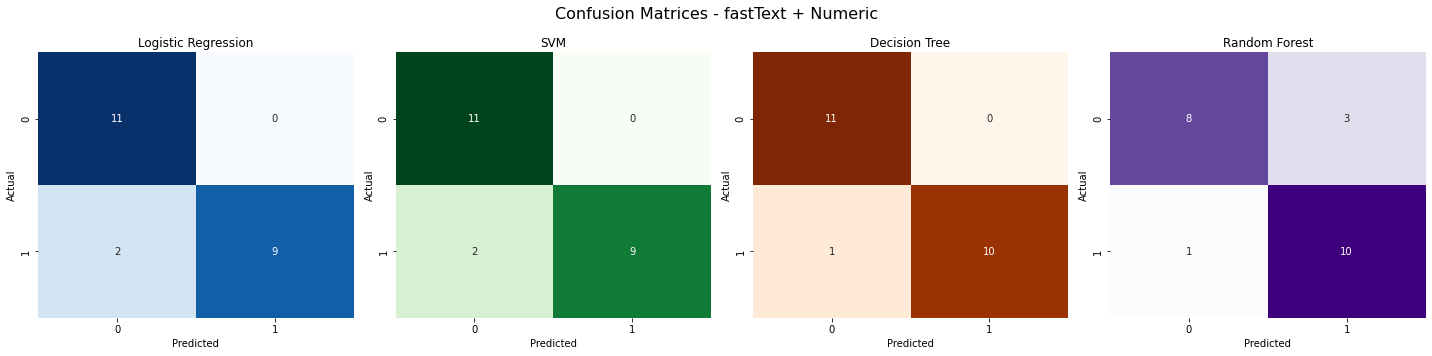

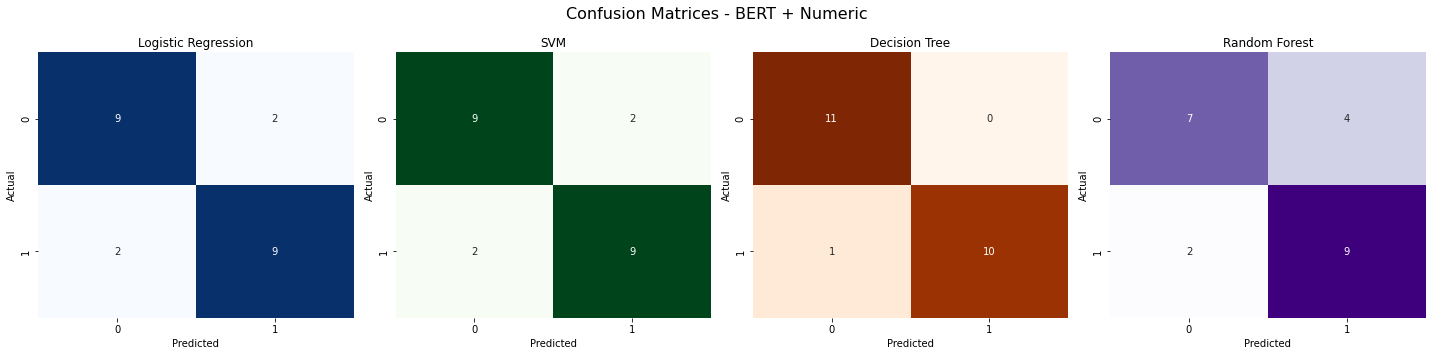

In [491]:
# Import Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define Models 
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Define feature sets
feature_sets = {
    "TF-IDF + Numeric": (X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf),
    "fastText + Numeric": (X_train_fasttext, X_val_fasttext, y_train_fasttext, y_val_fasttext),
    "BERT + Numeric": (X_train_bert, X_val_bert, y_train_bert, y_val_bert)
}

# Define Evaluation Function
def evaluate_model(name, model, X_train, X_val, y_train, y_val, results):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)

    results[name] = {
        'model': model,
        'y_true': y_val,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC AUC': auc
    }

# Run Evaluations
results_all = {}
for feat_name, (X_train, X_val, y_train, y_val) in feature_sets.items():
    # Important! Fresh models every time
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "SVM": SVC(probability=True),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier()
    }
    
    for model_name, model in models.items():
        full_name = f"{model_name} ({feat_name})"
        print(f"\n=== Evaluating {full_name} ===")
        evaluate_model(full_name, model, X_train, X_val, y_train, y_val, results_all)


# Combined ROC Plots
model_names = list(models.keys())
feature_keys = list(feature_sets.keys())
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, feat_name in enumerate(feature_keys):
    ax = axes[i]
    ax.set_title(f"ROC Curve - {feat_name}")    
    for model_name in model_names:
        key = f"{model_name} ({feat_name})"
        y_true = results_all[key]['y_true']
        y_proba = results_all[key]['y_proba']
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc_score = results_all[key]['ROC AUC']
        ax.plot(fpr, tpr, label=f"{model_name} (AUC: {auc_score:.2f})")    
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(True)
plt.suptitle("ROC Curves for All Models by Feature Set", fontsize=16)
plt.tight_layout()
plt.show()

# Confusion Matrix Grid
model_cmaps = {
    "Logistic Regression": "Blues",
    "SVM": "Greens",
    "Decision Tree": "Oranges",
    "Random Forest": "Purples"
}
for feat_name in feature_keys:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"Confusion Matrices - {feat_name}", fontsize=16)    
    for j, model_name in enumerate(model_names):
        key = f"{model_name} ({feat_name})"
        y_true = results_all[key]['y_true']
        y_pred = results_all[key]['y_pred']
        cm = confusion_matrix(y_true, y_pred)
        cmap = model_cmaps.get(model_name, "Blues")
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=axes[j])
        axes[j].set_title(model_name)
        axes[j].set_xlabel("Predicted")
        axes[j].set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [492]:
# Results Table
results_df = pd.DataFrame(results_all).T.drop(columns=["model", "y_true", "y_pred", "y_proba"])
results_df = results_df.sort_values(by="F1", ascending=False)
print("======================= Training Model Results Table (Sorted by F1 Score) =======================")
display(results_df.style.background_gradient(cmap='Blues'))

======================= Training Model Results Table (Sorted by F1 Score) =======================


,Accuracy,Precision,Recall,F1,ROC AUC
Decision Tree (TF-IDF + Numeric),0.954545,1.000000,0.909091,0.952381,0.954545
Decision Tree (fastText + Numeric),0.954545,1.000000,0.909091,0.952381,0.954545
Decision Tree (BERT + Numeric),0.954545,1.000000,0.909091,0.952381,0.954545
Logistic Regression (TF-IDF + Numeric),0.909091,1.000000,0.818182,0.900000,1.000000
SVM (TF-IDF + Numeric),0.909091,1.000000,0.818182,0.900000,0.983471
Logistic Regression (fastText + Numeric),0.909091,1.000000,0.818182,0.900000,1.000000
SVM (fastText + Numeric),0.909091,1.000000,0.818182,0.900000,0.983471
Random Forest (TF-IDF + Numeric),0.863636,1.000000,0.727273,0.842105,0.991736
Random Forest (fastText + Numeric),0.818182,0.769231,0.909091,0.833333,0.929752
Logistic Regression (BERT + Numeric),0.818182,0.818182,0.818182,0.818182,0.892562


In [493]:
# Decision Tree Models
DT_TFIDF = results_all["Decision Tree (TF-IDF + Numeric)"]['model']
DT_fastText = results_all["Decision Tree (fastText + Numeric)"]['model']
DT_BERT = results_all["Decision Tree (BERT + Numeric)"]['model']

print("Number of features expected by Decision Tree (TF-IDF):", DT_TFIDF.n_features_in_)
print("Number of features expected by Decision Tree (fastText):", DT_fastText.n_features_in_)
print("Number of features expected by Decision Tree (BERT):", DT_BERT.n_features_in_)

# Logistic Regression Models
LR_TFIDF = results_all["Logistic Regression (TF-IDF + Numeric)"]['model']
LR_fastText = results_all["Logistic Regression (fastText + Numeric)"]['model']
LR_BERT = results_all["Logistic Regression (BERT + Numeric)"]['model']

print("\nNumber of features expected by Logistic Regression (TF-IDF):", LR_TFIDF.n_features_in_)
print("Number of features expected by Logistic Regression (fastText):", LR_fastText.n_features_in_)
print("Number of features expected by Logistic Regression (BERT):", LR_BERT.n_features_in_)

# SVM Models
SVM_TFIDF = results_all["SVM (TF-IDF + Numeric)"]['model']
SVM_fastText = results_all["SVM (fastText + Numeric)"]['model']
SVM_BERT = results_all["SVM (BERT + Numeric)"]['model']

print("\nNumber of features expected by SVM (TF-IDF):", SVM_TFIDF.n_features_in_)
print("Number of features expected by SVM (fastText):", SVM_fastText.n_features_in_)
print("Number of features expected by SVM (BERT):", SVM_BERT.n_features_in_)

# Random Forest Models
RF_TFIDF = results_all["Random Forest (TF-IDF + Numeric)"]['model']
RF_fastText = results_all["Random Forest (fastText + Numeric)"]['model']
RF_BERT = results_all["Random Forest (BERT + Numeric)"]['model']

print("\nNumber of features expected by Random Forest (TF-IDF):", RF_TFIDF.n_features_in_)
print("Number of features expected by Random Forest (fastText):", RF_fastText.n_features_in_)
print("Number of features expected by Random Forest (BERT):", RF_BERT.n_features_in_)

Number of features expected by Decision Tree (TF-IDF): 685
Number of features expected by Decision Tree (fastText): 304
Number of features expected by Decision Tree (BERT): 772

Number of features expected by Logistic Regression (TF-IDF): 685
Number of features expected by Logistic Regression (fastText): 304
Number of features expected by Logistic Regression (BERT): 772

Number of features expected by SVM (TF-IDF): 685
Number of features expected by SVM (fastText): 304
Number of features expected by SVM (BERT): 772

Number of features expected by Random Forest (TF-IDF): 685
Number of features expected by Random Forest (fastText): 304
Number of features expected by Random Forest (BERT): 772


### 06. Evaluation on Test Set

##### 6.1. Test Set Preprocessing

In [ ]:
# Load the test set
test_df = pd.read_csv('Datasets/Testing_db.csv')

# Apply cleaning function to the test set
test_df['Cleaned_Transcript'] = test_df['Transcript'].apply(clean_transcript)

# ------------------- Numeric Features -------------------
# Encode gender
gender_map = {"male": 0, "female": 1}
test_df["GenderEncoded"] = test_df["Gender"].map(gender_map)

# Word count feature
test_df['Transcript_Length'] = test_df['Cleaned_Transcript'].apply(lambda x: len(x.split()))
test_df.head()

,Data,Participant,Age,Gender,Diagnosis,Category,mmse,Filename,Transcript,Cleaned_Transcript,GenderEncoded,Transcript_Length
0,Pitt,PAR,63,female,Control,0,28,S160,&uh this boy is about to fall off o(f) the st...,this boy is about to fall off of the stool the...,1,42
1,Pitt,PAR,55,female,Control,0,29,S161,&uh a boy with a cookie in his one hand and h...,a boy with a cookie in his one hand and his ha...,1,108
2,Pitt,PAR,67,female,ProbableAD,1,24,S162,"I see &uh two kids up at the cookie jar, one ...",i see two kid up at the cookie jar one on a st...,1,97
3,Pitt,PAR,71,male,Control,0,30,S163,okay the water's running out_of the sink over...,okay the water running outof the sink overflow...,0,139
4,Pitt,PAR,73,female,ProbableAD,1,21,S164,well he's into the cookie jar and the [/] the...,well he into the cookie jar and the the stool ...,1,50


##### 6.2. Feature Extraction for Test Set

6.2.1. TF-IDF

In [495]:
# Transform text using TF-IDF vectorizer (same one used in training!)
X_test_text_tfidf = tfidf_vectorizer.transform(test_df['Cleaned_Transcript']).toarray()

# Scale numeric features (use same scaler fitted on train)
X_test_numeric = test_df[['mmse', 'Transcript_Length', 'GenderEncoded', 'Age']]
X_test_numeric_scaled = scaler_tfidf.transform(X_test_numeric)

# Combine text and numeric features
X_test_final_tfidf = np.hstack((X_test_text_tfidf, X_test_numeric_scaled))

print(f"TF-IDF Test feature shape: {X_test_final_tfidf.shape}")

TF-IDF Test feature shape: (48, 685)


6.2.2. FastText

In [496]:
# Generate fastText features for test
X_test_text_fasttext = np.array([get_avg_fasttext_vector(text, model_fasttext) for text in test_df['Cleaned_Transcript']])

# Scale numeric features using same scaler as before (used for fastText training)
X_test_numeric_scaled_fasttext = scaler_fasttext.transform(test_df[['mmse', 'Transcript_Length', 'GenderEncoded', 'Age']])

# Combine
X_test_final_fasttext = np.hstack((X_test_text_fasttext, X_test_numeric_scaled_fasttext))

print(f"fastText Test feature shape: {X_test_final_fasttext.shape}")


fastText Test feature shape: (48, 304)


6.2.3. BERT

In [497]:
# Apply to your test set
X_test_text_bert = np.array([get_bert_cls_embedding(text) for text in test_df['Cleaned_Transcript']])
print(f"BERT Test Embedding Shape: {X_test_text_bert.shape}")

# Scale numeric features using the same scaler you fitted on training data
X_test_numeric_bert = test_df[['mmse', 'Transcript_Length', 'GenderEncoded', 'Age']]
X_test_numeric_scaled_bert = scaler_bert.transform(X_test_numeric_bert)

# Combine text embeddings + numeric features
X_test_final_bert = np.hstack((X_test_text_bert, X_test_numeric_scaled_bert))

print(f"BERT + Numeric Test Features Shape: {X_test_final_bert.shape}")

BERT Test Embedding Shape: (48, 768)
BERT + Numeric Test Features Shape: (48, 772)


##### 6.3. Evaluate the models on TestSet

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Define models and matching test features
test_models = {
    "Decision Tree (TF-IDF)": (DT_TFIDF, X_test_final_tfidf),
    "Logistic Regression (TF-IDF)": (LR_TFIDF, X_test_final_tfidf),
    "SVM (TF-IDF)": (SVM_TFIDF, X_test_final_tfidf),
    "Random Forest (TF-IDF)": (RF_TFIDF, X_test_final_tfidf),
    
    "Decision Tree (fastText)": (DT_fastText, X_test_final_fasttext),
    "Logistic Regression (fastText)": (LR_fastText, X_test_final_fasttext),
    "SVM (fastText)": (SVM_fastText, X_test_final_fasttext),
    "Random Forest (fastText)": (RF_fastText, X_test_final_fasttext),
    
    "Decision Tree (BERT)": (DT_BERT, X_test_final_bert),
    "Logistic Regression (BERT)": (LR_BERT, X_test_final_bert),
    "SVM (BERT)": (SVM_BERT, X_test_final_bert),
    "Random Forest (BERT)": (RF_BERT, X_test_final_bert)
}

# Load True Labels
labels_df = pd.read_csv("Datasets/2020Labels.txt", sep=";")
labels_df.columns = labels_df.columns.str.strip()
y_test_true = labels_df['Label'].values

# Store results
test_results = {}

# Evaluate all models
for model_name, (model, X_test_feat) in test_models.items():
    print(f"\n=== Evaluating {model_name} on Test Set ===")
    y_test_pred = model.predict(X_test_feat)
    y_test_proba = model.predict_proba(X_test_feat)[:, 1]

    acc = accuracy_score(y_test_true, y_test_pred)
    prec = precision_score(y_test_true, y_test_pred)
    rec = recall_score(y_test_true, y_test_pred)
    f1 = f1_score(y_test_true, y_test_pred)
    auc = roc_auc_score(y_test_true, y_test_proba)

    print(classification_report(y_test_true, y_test_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_true, y_test_pred))
    print("ROC AUC Score:", auc)

    # Save
    test_results[model_name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC AUC": auc
    }


=== Evaluating Decision Tree (TF-IDF) on Test Set ===
              precision    recall  f1-score   support

           0       0.85      0.96      0.90        24
           1       0.95      0.83      0.89        24

    accuracy                           0.90        48
   macro avg       0.90      0.90      0.90        48
weighted avg       0.90      0.90      0.90        48

Confusion Matrix:
[[23  1]
 [ 4 20]]
ROC AUC Score: 0.8958333333333335

=== Evaluating Logistic Regression (TF-IDF) on Test Set ===
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        24
           1       1.00      0.79      0.88        24

    accuracy                           0.90        48
   macro avg       0.91      0.90      0.89        48
weighted avg       0.91      0.90      0.89        48

Confusion Matrix:
[[24  0]
 [ 5 19]]
ROC AUC Score: 0.9774305555555556

=== Evaluating SVM (TF-IDF) on Test Set ===
              precision    recall  f1-score

[[24  0]
 [ 7 17]]
ROC AUC Score: 0.9444444444444444

=== Evaluating Random Forest (fastText) on Test Set ===
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        24
           1       0.86      0.79      0.83        24

    accuracy                           0.83        48
   macro avg       0.84      0.83      0.83        48
weighted avg       0.84      0.83      0.83        48

Confusion Matrix:
[[21  3]
 [ 5 19]]
ROC AUC Score: 0.9479166666666666

=== Evaluating Decision Tree (BERT) on Test Set ===
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        24
           1       0.91      0.88      0.89        24

    accuracy                           0.90        48
   macro avg       0.90      0.90      0.90        48
weighted avg       0.90      0.90      0.90        48

Confusion Matrix:
[[22  2]
 [ 3 21]]
ROC AUC Score: 0.8958333333333334

=== Evaluating Logistic Regression (BERT

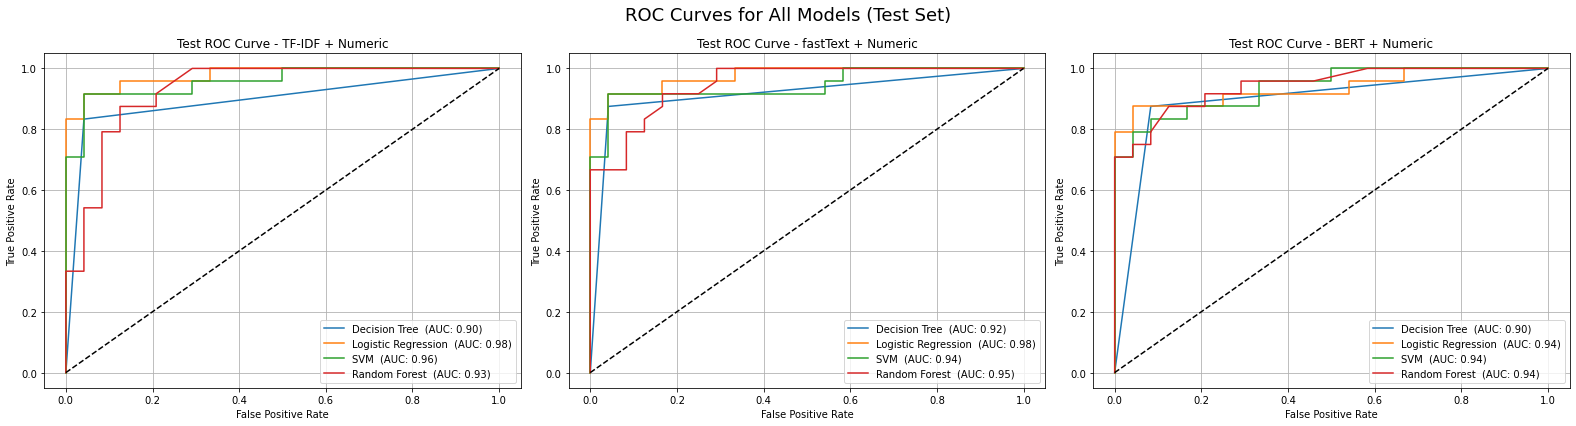

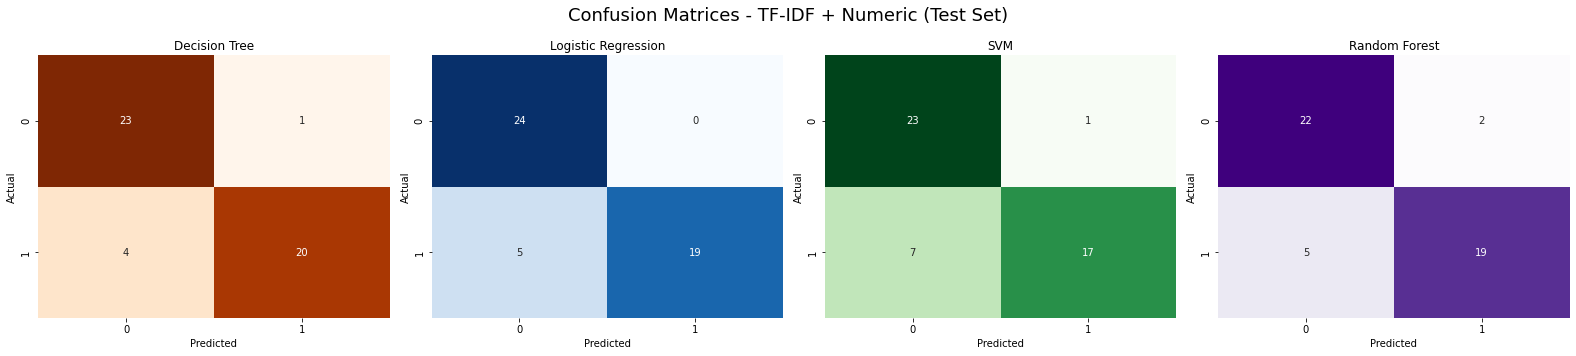

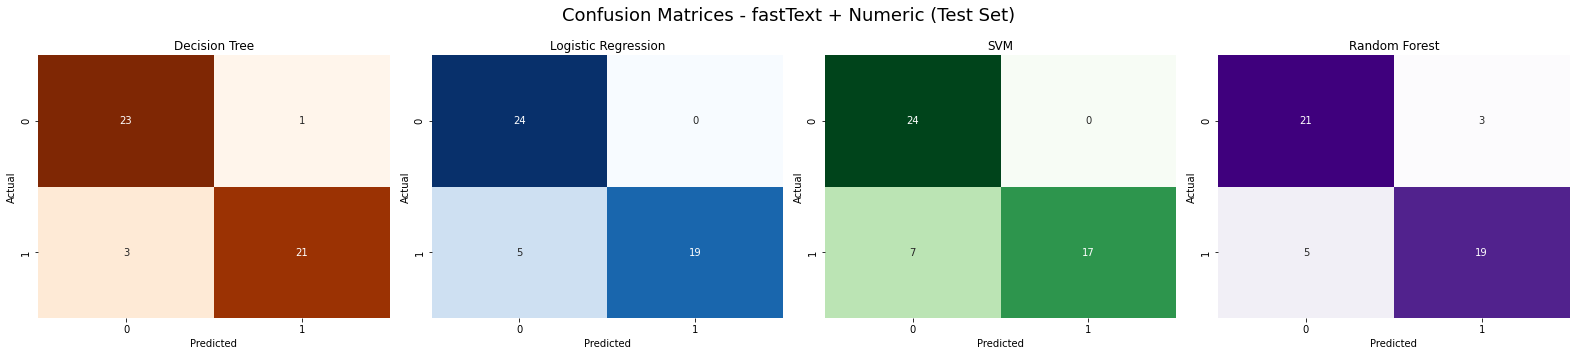

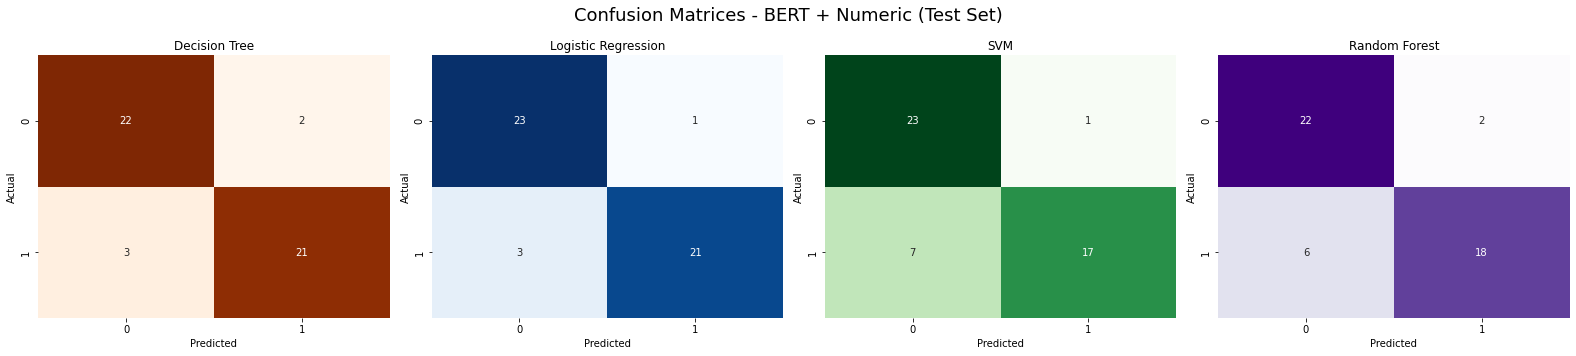

In [499]:
# Group models by feature type
feature_model_map = {
    "TF-IDF + Numeric": ["Decision Tree (TF-IDF)", "Logistic Regression (TF-IDF)", "SVM (TF-IDF)", "Random Forest (TF-IDF)"],
    "fastText + Numeric": ["Decision Tree (fastText)", "Logistic Regression (fastText)", "SVM (fastText)", "Random Forest (fastText)"],
    "BERT + Numeric": ["Decision Tree (BERT)", "Logistic Regression (BERT)", "SVM (BERT)", "Random Forest (BERT)"]
}

model_cmaps = {
    "Logistic Regression": "Blues",
    "SVM": "Greens",
    "Decision Tree": "Oranges",
    "Random Forest": "Purples"
}

# --- ROC CURVES ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for i, (feat_name, model_list) in enumerate(feature_model_map.items()):
    ax = axes[i]
    ax.set_title(f"Test ROC Curve - {feat_name}")
    for model_name in model_list:
        model, X_test_feat = test_models[model_name]
        y_test_pred = model.predict(X_test_feat)
        y_test_proba = model.predict_proba(X_test_feat)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_true, y_test_proba)
        auc_score = roc_auc_score(y_test_true, y_test_proba)
        ax.plot(fpr, tpr, label=f"{model_name.split('(')[0]} (AUC: {auc_score:.2f})")
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(True)
plt.suptitle("ROC Curves for All Models (Test Set)", fontsize=18)
plt.tight_layout()
plt.show()

# --- CONFUSION MATRICES ---
for feat_name, model_list in feature_model_map.items():
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(f"Confusion Matrices - {feat_name} (Test Set)", fontsize=18)
    for j, model_name in enumerate(model_list):
        model, X_test_feat = test_models[model_name]
        y_test_pred = model.predict(X_test_feat)
        cm = confusion_matrix(y_test_true, y_test_pred)
        base_model = model_name.split('(')[0].strip()
        cmap = model_cmaps.get(base_model, "Blues")
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=axes[j])
        axes[j].set_title(base_model)
        axes[j].set_xlabel("Predicted")
        axes[j].set_ylabel("Actual")
    plt.tight_layout()
    plt.show()


In [500]:
# Create a summary DataFrame
test_results_df = pd.DataFrame(test_results).T
test_results_df = test_results_df.sort_values(by="F1", ascending=False)
print("======================= Test Model Results Table (Sorted by F1 Score) =======================")
display(test_results_df.style.background_gradient(cmap='Blues'))

======================= Test Model Results Table (Sorted by F1 Score) =======================


,Accuracy,Precision,Recall,F1,ROC AUC
Decision Tree (fastText),0.916667,0.954545,0.875000,0.913043,0.916667
Logistic Regression (BERT),0.916667,0.954545,0.875000,0.913043,0.935764
Decision Tree (BERT),0.895833,0.913043,0.875000,0.893617,0.895833
Decision Tree (TF-IDF),0.895833,0.952381,0.833333,0.888889,0.895833
Logistic Regression (TF-IDF),0.895833,1.000000,0.791667,0.883721,0.977431
Logistic Regression (fastText),0.895833,1.000000,0.791667,0.883721,0.975694
Random Forest (TF-IDF),0.854167,0.904762,0.791667,0.844444,0.930556
SVM (fastText),0.854167,1.000000,0.708333,0.829268,0.944444
Random Forest (fastText),0.833333,0.863636,0.791667,0.826087,0.947917
Random Forest (BERT),0.833333,0.900000,0.750000,0.818182,0.943576
